# 🔬 Chronos-2 Evaluation for RUL Prediction

**Objective**: Evaluate Chronos-2 foundation model with different regression heads (Ridge, MLP, XGBoost, LSTM, BiLSTM) for Remaining Useful Life prediction on C-MAPSS FD001

**Structure**:
- **Part A**: Data Preparation & Feature Selection (Correlation + AFICv)
- **Part B**: Chronos-2 Embedding Extraction (native multivariate)
- **Part C**: Regression Heads Evaluation (Ridge, MLP, XGBoost, LSTM, BiLSTM)
- **Part D**: Comparison with IMSA2025 Baselines

**Key Novelty**: Chronos-2 supports native multivariate forecasting via group attention mechanism, capturing inter-sensor dependencies.

**Baselines** (from IMSA2025 paper):
- Proposed LSTM: RMSE=14.32, Score=325.05
- XGBoost (direct): RMSE=14.64, Score=307.13
- Chronos-1 + XGBoost: RMSE=15.93, Score=379.02

**Author**: Fatima Khadija Benzine — March 2026


---
## 0. Setup & Installation

In [2]:
# Install dependencies
!pip install -q 'chronos-forecasting>=2.2' xgboost torch

import os
if not os.path.exists('/content/PhD-Project-'):
    !git clone https://github.com/f-khadija-benzine/PhD-Project-.git /content/PhD-Project-

os.chdir('/content/PhD-Project-/src')

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
from datetime import datetime
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import json, time, warnings
warnings.filterwarnings('ignore')

import torch
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

from data_loader import MultiDatasetLoader
from preprocessing import DataNormalizer

TIMESTAMP = datetime.now().strftime('%Y%m%d_%H%M')
SAVE_DIR = f'/content/drive/MyDrive/PhD_results/Chronos_Eval_{TIMESTAMP}'
os.makedirs(SAVE_DIR, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {DEVICE}")
print(f"Save directory: {SAVE_DIR}")
print("Setup complete ✓")

Mounted at /content/drive
Device: cuda
Save directory: /content/drive/MyDrive/PhD_results/Chronos_Eval_20260308_0016
Setup complete ✓


---
## Part A: Data Preparation & Feature Selection

In [3]:
# === A1: Load C-MAPSS FD001 ===
DATASET = 'FD001'
W = 30
RUL_CAP = 125

loader = MultiDatasetLoader()
ds = loader.load_cmapss_dataset(DATASET)

train_raw = ds['train'].copy()
test_raw = ds['test'].copy()

# Apply RUL cap
train_raw['rul'] = train_raw['rul'].clip(upper=RUL_CAP)
if 'rul' in test_raw.columns:
    test_raw['rul'] = test_raw['rul'].clip(upper=RUL_CAP)

sensor_cols = [c for c in train_raw.columns if c.startswith('sensor_')]
setting_cols = [c for c in train_raw.columns if c.startswith('setting_')]
feature_cols = sensor_cols + setting_cols

print(f"✓ Data loaded")
print(f"  Train: {len(train_raw)} samples, {train_raw['unit'].nunique()} units")
print(f"  Test: {len(test_raw)} samples, {test_raw['unit'].nunique()} units")
print(f"  Features: {len(feature_cols)} ({len(sensor_cols)} sensors + {len(setting_cols)} settings)")

Loading FD001 dataset...
  Files: train=True, test=True, rul=True
  - Training data shape: (20631, 26)
  - Training units: 100
  - Training RUL range: [0, 361]
  - Test data shape: (13096, 26)
  - RUL values shape: (100, 1)
  - Test units found: 100 (units: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]...)
  - RUL values provided: 100
    Unit 1: max_cycle=31, base_RUL=112
    Unit 2: max_cycle=49, base_RUL=98
    Unit 3: max_cycle=126, base_RUL=69
✓ FD001 loaded: 20631 train, 13096 test samples
✓ Data loaded
  Train: 20631 samples, 100 units
  Test: 13096 samples, 100 units
  Features: 24 (21 sensors + 3 settings)


In [4]:
# === A2: Normalization ===
norm = DataNormalizer(method='minmax')
train_norm = norm.fit_transform(train_raw, feature_cols)
test_norm = norm.transform(test_raw)

print(f"✓ Normalization complete (MinMax)")

✓ Normalization complete (MinMax)


In [5]:
# === A3: Feature Selection ===

def variance_filter(df, feature_cols, threshold=0.001):
    """Remove low-variance features"""
    variances = df[feature_cols].var()
    selected = variances[variances > threshold].index.tolist()
    removed = [f for f in feature_cols if f not in selected]
    return selected, removed

def correlation_filter(df, feature_cols, threshold=0.95):
    """Remove highly correlated features"""
    corr_matrix = df[feature_cols].corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    selected = [f for f in feature_cols if f not in to_drop]
    return selected, to_drop

def aficv_selection(df, feature_cols, target_col='rul', threshold=0.90):
    """AFICv: Accumulated Feature Importance with Cross-Validation"""
    X = df[feature_cols].values
    y = df[target_col].values

    model = XGBRegressor(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1)
    model.fit(X, y)

    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]

    cumsum = np.cumsum(importances[indices])
    n_features = np.searchsorted(cumsum, threshold) + 1

    selected_indices = indices[:n_features]
    selected = [feature_cols[i] for i in selected_indices]

    return selected, cumsum[n_features-1]

# Strategy 1: Variance + Correlation filtering
print("=== Strategy 1: Variance + Correlation Filtering ===")
feats_var, removed_var = variance_filter(train_norm, feature_cols, threshold=0.001)
print(f"  Variance filter: {len(feature_cols)} → {len(feats_var)} (removed: {removed_var})")

feats_corr, removed_corr = correlation_filter(train_norm, feats_var, threshold=0.95)
print(f"  Correlation filter: {len(feats_var)} → {len(feats_corr)} (removed: {removed_corr})")

# Strategy 2: AFICv
print("\n=== Strategy 2: AFICv (90% importance coverage) ===")
feats_aficv, coverage = aficv_selection(train_norm, feature_cols, threshold=0.90)
print(f"  Selected: {len(feats_aficv)} features (coverage: {coverage:.1%})")
print(f"  Features: {feats_aficv}")

# Store feature sets
feature_sets = {
    'correlation': feats_corr,
    'aficv': feats_aficv
}

print("\n=== Summary ===")
for name, feats in feature_sets.items():
    print(f"  {name}: {len(feats)} features")

=== Strategy 1: Variance + Correlation Filtering ===
  Variance filter: 24 → 17 (removed: ['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19', 'setting_3'])
  Correlation filter: 17 → 16 (removed: ['sensor_14'])

=== Strategy 2: AFICv (90% importance coverage) ===
  Selected: 8 features (coverage: 90.4%)
  Features: ['sensor_11', 'sensor_9', 'sensor_4', 'sensor_12', 'sensor_20', 'sensor_15', 'sensor_17', 'sensor_14']

=== Summary ===
  correlation: 16 features
  aficv: 8 features


In [6]:
# === A4: Create Sliding Windows ===

def create_sliding_windows(df, feature_cols, window_size=30):
    """Create sliding windows for each unit"""
    X_list, y_list, unit_list = [], [], []

    for unit in sorted(df['unit'].unique()):
        unit_data = df[df['unit'] == unit].sort_values('cycle')
        n_samples = len(unit_data)

        if n_samples < window_size:
            continue

        values = unit_data[feature_cols].values
        ruls = unit_data['rul'].values

        for start in range(n_samples - window_size + 1):
            end = start + window_size
            X_list.append(values[start:end])
            y_list.append(ruls[end - 1])
            unit_list.append(unit)

    return np.array(X_list), np.array(y_list), np.array(unit_list)

# Create windows for each feature set
data_dict = {}

for fs_name, features in feature_sets.items():
    X_train, y_train, units_train = create_sliding_windows(train_norm, features, W)
    X_test, y_test, units_test = create_sliding_windows(test_norm, features, W)

    data_dict[fs_name] = {
        'X_train': X_train, 'y_train': y_train, 'units_train': units_train,
        'X_test': X_test, 'y_test': y_test, 'units_test': units_test,
        'features': features
    }

    print(f"{fs_name}: X_train={X_train.shape}, X_test={X_test.shape}")

print("\n✓ Sliding windows created")

correlation: X_train=(17731, 30, 16), X_test=(10196, 30, 16)
aficv: X_train=(17731, 30, 8), X_test=(10196, 30, 8)

✓ Sliding windows created


In [7]:
# === A5: Evaluation Helpers ===

def nasa_score(y_true, y_pred):
    """NASA asymmetric scoring function (Saxena et al. 2008)"""
    d = y_pred - y_true
    score = np.where(d < 0, np.exp(-d/13) - 1, np.exp(d/10) - 1)
    return np.sum(score)

def evaluate_per_unit(y_true, y_pred, unit_labels):
    """Evaluate using last prediction per unit (standard C-MAPSS protocol)"""
    preds_last, true_last = [], []
    for u in sorted(set(unit_labels)):
        mask = unit_labels == u
        if mask.sum() > 0:
            preds_last.append(y_pred[mask][-1])
            true_last.append(y_true[mask][-1])

    preds_last = np.array(preds_last)
    true_last = np.array(true_last)

    rmse = np.sqrt(mean_squared_error(true_last, preds_last))
    score = nasa_score(true_last, preds_last)
    return rmse, score

ALL_RESULTS = []
print("Evaluation helpers ✓")

Evaluation helpers ✓


Window 0: Unit 1, RUL = 113
Shape: (30, 16) (window_size=30, n_features=16)


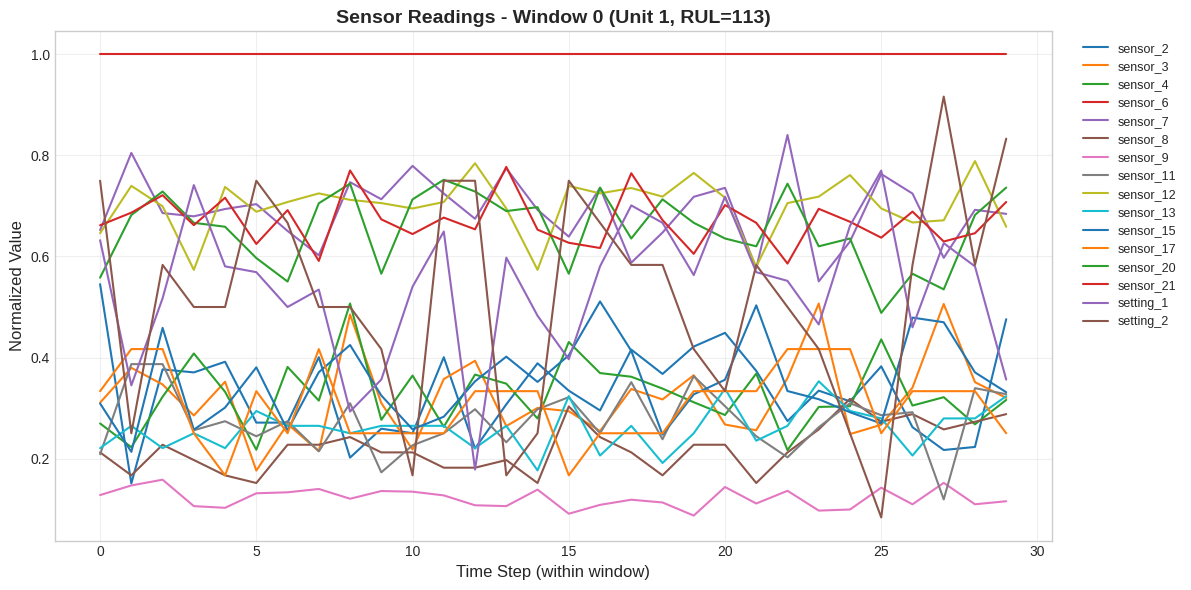

In [8]:
# === Visualisation d'une fenêtre temporelle ===

fs_name = 'correlation'
features = feature_sets[fs_name]
X_data = data_dict[fs_name]['X_test']  # (n_samples, window_size, n_features)
y_data = data_dict[fs_name]['y_test']
units = data_dict[fs_name]['units_test']

# Choisir une fenêtre à visualiser
window_idx = 0  # Première fenêtre (change pour voir d'autres)

print(f"Window {window_idx}: Unit {units[window_idx]}, RUL = {y_data[window_idx]:.0f}")
print(f"Shape: {X_data[window_idx].shape} (window_size={W}, n_features={len(features)})")

# Plot 1: Toutes les features sur un seul graphe
fig, ax = plt.subplots(figsize=(12, 6))

window = X_data[window_idx]  # (window_size, n_features)
time_steps = np.arange(W)

for i, feat in enumerate(features):
    ax.plot(time_steps, window[:, i], label=feat, linewidth=1.5)

ax.set_xlabel('Time Step (within window)', fontsize=12)
ax.set_ylabel('Normalized Value', fontsize=12)
ax.set_title(f'Sensor Readings - Window {window_idx} (Unit {units[window_idx]}, RUL={y_data[window_idx]:.0f})',
             fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/window_example_{window_idx}_{TIMESTAMP}.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part B: Chronos-1 Evaluation

**Approach**: Extract embeddings using Chronos encoder → Train regression head for RUL prediction

**Note**: Chronos-1 is univariate, so we process each sensor separately and concatenate embeddings.

In [ ]:
# === B1: Load Chronos-1 Pipeline ===
from chronos import ChronosPipeline

CHRONOS1_MODEL = "amazon/chronos-t5-small"

print(f"Loading Chronos-1: {CHRONOS1_MODEL}...")
chronos1_pipeline = ChronosPipeline.from_pretrained(
    CHRONOS1_MODEL,
    device_map=DEVICE,
    torch_dtype=torch.float32
)
print("Chronos-1 loaded ✓")
print(f"  Architecture: T5 encoder-decoder")
print(f"  Capability: Univariate only")

In [ ]:
# === B2: Extract Chronos-1 Embeddings ===

def extract_chronos1_embeddings(pipeline, X, batch_size=32):
    """
    Extract Chronos-1 encoder embeddings.
    X shape: (n_samples, window_size, n_features)
    Since Chronos-1 is univariate, we process each feature and concatenate.
    """
    n_samples, window_size, n_features = X.shape
    all_embeddings = []

    for i in range(0, n_samples, batch_size):
        batch = X[i:i+batch_size]
        batch_embeddings = []

        for feat_idx in range(n_features):
            feat_data = batch[:, :, feat_idx]
            ts_tensor = torch.tensor(feat_data, dtype=torch.float32).to(DEVICE)

            with torch.no_grad():
                emb = pipeline.embed(ts_tensor)
                emb_pooled = emb.mean(dim=1).cpu().numpy()

            batch_embeddings.append(emb_pooled)

        combined = np.concatenate(batch_embeddings, axis=1)
        all_embeddings.append(combined)

        if (i // batch_size) % 10 == 0:
            print(f"    Processed {min(i+batch_size, n_samples)}/{n_samples} samples")

    return np.vstack(all_embeddings)

print("Chronos-1 embedding function defined ✓")

In [ ]:
# === B3: Chronos-1 Evaluation ===

chronos1_results = {}

for fs_name in feature_sets.keys():
    print(f"\n{'='*60}")
    print(f"Chronos-1 + {fs_name.upper()} ({len(feature_sets[fs_name])} features)")
    print('='*60)

    data = data_dict[fs_name]

    print("Extracting train embeddings...")
    start_time = time.time()
    X_train_emb = extract_chronos1_embeddings(chronos1_pipeline, data['X_train'])
    train_time = time.time() - start_time
    print(f"  Shape: {X_train_emb.shape}, Time: {train_time:.1f}s")

    print("Extracting test embeddings...")
    start_time = time.time()
    X_test_emb = extract_chronos1_embeddings(chronos1_pipeline, data['X_test'])
    test_time = time.time() - start_time
    print(f"  Shape: {X_test_emb.shape}, Time: {test_time:.1f}s")

    heads = [
        ('Ridge', Ridge(alpha=1.0)),
        ('MLP', MLPRegressor(hidden_layer_sizes=(256, 128), max_iter=500, random_state=42)),
        ('XGBoost', XGBRegressor(n_estimators=100, max_depth=5, random_state=42))
    ]

    for head_name, head_model in heads:
        print(f"\n  Training {head_name} head...")
        head_model.fit(X_train_emb, data['y_train'])

        y_pred = head_model.predict(X_test_emb)
        rmse, score = evaluate_per_unit(data['y_test'], y_pred, data['units_test'])

        result = {
            'Model': 'Chronos-1',
            'Feature_Set': fs_name,
            'Head': head_name,
            'Test_RMSE': round(rmse, 2),
            'Test_Score': round(score, 1),
            'Time_sec': round(train_time + test_time, 1)
        }
        ALL_RESULTS.append(result)
        chronos1_results[f"{fs_name}_{head_name}"] = result

        print(f"    RMSE: {rmse:.2f}, Score: {score:.1f}")

print("\n✓ Chronos-1 evaluation complete")

---
## Part C: Chronos-2 Evaluation

**Advantage**: Chronos-2 supports native multivariate forecasting via group attention mechanism.

In [9]:
# === C1: Load Chronos-2 Pipeline ===
from chronos import Chronos2Pipeline

CHRONOS2_MODEL = "amazon/chronos-2"

print(f"Loading Chronos-2: {CHRONOS2_MODEL}...")
chronos2_pipeline = Chronos2Pipeline.from_pretrained(
    CHRONOS2_MODEL,
    device_map=DEVICE
)
print("Chronos-2 loaded ✓")
print(f"  Parameters: 120M")
print(f"  Architecture: Encoder-only + Group Attention")
print(f"  Capabilities: Univariate, Multivariate")

Loading Chronos-2: amazon/chronos-2...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/478M [00:00<?, ?B/s]

Chronos-2 loaded ✓
  Parameters: 120M
  Architecture: Encoder-only + Group Attention
  Capabilities: Univariate, Multivariate


In [8]:
# === C2: Extract Chronos-2 Embeddings (Multivariate) ===

def extract_chronos2_embeddings(pipeline, X, batch_size=32):
    """
    Extract Chronos-2 encoder embeddings.
    Chronos-2 can process multivariate series natively.
    X shape: (n_samples, window_size, n_features)
    """
    n_samples, window_size, n_features = X.shape
    all_embeddings = []

    for i in range(0, n_samples, batch_size):
        batch = X[i:i+batch_size]
        batch_t = np.transpose(batch, (0, 2, 1))

        ts_tensor = torch.tensor(batch_t, dtype=torch.float32)

        with torch.no_grad():
            result = pipeline.embed(ts_tensor)
            # embed() returns (embeddings, loc_scale) tuple
            emb = result[0] if isinstance(result, tuple) else result
            emb_pooled = emb.mean(dim=1).cpu().numpy()

        all_embeddings.append(emb_pooled)

        if (i // batch_size) % 10 == 0:
            print(f"    Processed {min(i+batch_size, n_samples)}/{n_samples} samples")

    return np.vstack(all_embeddings)

print("Chronos-2 embedding function defined ✓")

Chronos-2 embedding function defined ✓


In [9]:
# === C2: Extract Chronos-2 Embeddings (Multivariate) ===

def extract_chronos2_embeddings(pipeline, X, batch_size=32):
    """
    Extract Chronos-2 encoder embeddings.
    X shape: (n_samples, window_size, n_features)
    """
    n_samples, window_size, n_features = X.shape
    all_embeddings = []

    for i in range(0, n_samples, batch_size):
        batch = X[i:i+batch_size]
        batch_t = np.transpose(batch, (0, 2, 1))

        ts_tensor = torch.tensor(batch_t, dtype=torch.float32)

        with torch.no_grad():
            result = pipeline.embed(ts_tensor)

            # embed() returns (list of embeddings, loc_scale)
            emb_list = result[0]
            # Stack list of tensors: (batch, n_features, n_patches, embed_dim)
            emb = torch.stack(emb_list)
            # Mean over features and patches -> (batch, embed_dim)
            emb_pooled = emb.mean(dim=(1, 2)).cpu().numpy()

        all_embeddings.append(emb_pooled)

        if (i // batch_size) % 10 == 0:
            print(f"    Processed {min(i+batch_size, n_samples)}/{n_samples} samples")

    return np.vstack(all_embeddings)

print("Chronos-2 embedding function defined ✓")

Chronos-2 embedding function defined ✓


In [10]:
# === C2b: Different Embedding Pooling Strategies ===

def extract_chronos2_embeddings_v2(pipeline, X, batch_size=32, pooling='mean'):
    """
    Extract Chronos-2 embeddings with different pooling strategies.

    Args:
        pooling: 'mean' | 'last' | 'concat'
            - mean: Average over features and patches (current approach)
            - last: Take only the last patch embedding
            - concat: Concatenate all patch embeddings (larger dim)
    """
    n_samples, window_size, n_features = X.shape
    all_embeddings = []

    for i in range(0, n_samples, batch_size):
        batch = X[i:i+batch_size]
        batch_t = np.transpose(batch, (0, 2, 1))  # (batch, features, window)
        ts_tensor = torch.tensor(batch_t, dtype=torch.float32)

        with torch.no_grad():
            result = pipeline.embed(ts_tensor)
            emb_list = result[0]  # list of tensors
            emb = torch.stack(emb_list)  # (batch, n_features, n_patches, embed_dim)

            if pooling == 'mean':
                # Current: mean over features and patches -> (batch, embed_dim)
                emb_pooled = emb.mean(dim=(1, 2)).cpu().numpy()

            elif pooling == 'last':
                # Take last patch only, mean over features -> (batch, embed_dim)
                emb_pooled = emb[:, :, -1, :].mean(dim=1).cpu().numpy()

            elif pooling == 'concat':
                # Concatenate all patches, mean over features -> (batch, n_patches * embed_dim)
                batch_size_actual = emb.shape[0]
                n_patches = emb.shape[2]
                embed_dim = emb.shape[3]
                # Mean over features first -> (batch, n_patches, embed_dim)
                emb_feat_mean = emb.mean(dim=1)
                # Flatten patches -> (batch, n_patches * embed_dim)
                emb_pooled = emb_feat_mean.reshape(batch_size_actual, -1).cpu().numpy()

            elif pooling == 'last_concat':
                # Concatenate last patch from all features -> (batch, n_features * embed_dim)
                emb_pooled = emb[:, :, -1, :].reshape(emb.shape[0], -1).cpu().numpy()

        all_embeddings.append(emb_pooled)

    return np.vstack(all_embeddings)

print("Pooling strategies defined:")
print("  - mean: (batch, 768) - current approach")
print("  - last: (batch, 768) - last patch only")
print("  - concat: (batch, n_patches * 768) - all patches concatenated")
print("  - last_concat: (batch, n_features * 768) - last patch per feature")

Pooling strategies defined:
  - mean: (batch, 768) - current approach
  - last: (batch, 768) - last patch only
  - concat: (batch, n_patches * 768) - all patches concatenated
  - last_concat: (batch, n_features * 768) - last patch per feature


In [11]:
# === C3: Chronos-2 Evaluation ===

# Initialize prediction storage
all_predictions = {}

chronos2_results = {}

for fs_name in feature_sets.keys():
    print(f"\n{'='*60}")
    print(f"Chronos-2 + {fs_name.upper()} ({len(feature_sets[fs_name])} features)")
    print('='*60)

    # Initialize storage for this feature set
    all_predictions[fs_name] = {}

    data = data_dict[fs_name]

    print("Extracting train embeddings (multivariate)...")
    start_time = time.time()
    X_train_emb = extract_chronos2_embeddings(chronos2_pipeline, data['X_train'])
    train_time = time.time() - start_time
    print(f"  Shape: {X_train_emb.shape}, Time: {train_time:.1f}s")

    print("Extracting test embeddings...")
    start_time = time.time()
    X_test_emb = extract_chronos2_embeddings(chronos2_pipeline, data['X_test'])
    test_time = time.time() - start_time
    print(f"  Shape: {X_test_emb.shape}, Time: {test_time:.1f}s")

    heads = [
        ('Ridge', Ridge(alpha=1.0)),
        ('MLP', MLPRegressor(hidden_layer_sizes=(256, 128), max_iter=500, random_state=456)),
        ('XGBoost', XGBRegressor(n_estimators=100, max_depth=5, random_state=456))
    ]

    for head_name, head_model in heads:
        print(f"\n  Training {head_name} head...")
        head_model.fit(X_train_emb, data['y_train'])

        y_pred = head_model.predict(X_test_emb)

        # Store predictions for visualization
        all_predictions[fs_name][head_name] = {
            'y_pred': y_pred.copy(),
            'y_test': data['y_test'].copy(),
            'units_test': data['units_test'].copy()
        }

        rmse, score = evaluate_per_unit(data['y_test'], y_pred, data['units_test'])

        result = {
            'Model': 'Chronos-2',
            'Feature_Set': fs_name,
            'Head': head_name,
            'Test_RMSE': round(rmse, 2),
            'Test_Score': round(score, 1),
            'Time_sec': round(train_time + test_time, 1)
        }
        ALL_RESULTS.append(result)
        chronos2_results[f"{fs_name}_{head_name}"] = result

        print(f"    RMSE: {rmse:.2f}, Score: {score:.1f}")

print("\n✓ Chronos-2 evaluation complete")
print(f"✓ Predictions stored for visualization: {list(all_predictions.keys())}")


Chronos-2 + CORRELATION (16 features)
Extracting train embeddings (multivariate)...


NameError: name 'extract_chronos2_embeddings' is not defined

In [12]:
# === C2c: Evaluate All Pooling Strategies ===

pooling_strategies = ['mean', 'last', 'concat', 'last_concat']
pooling_results = []

fs_name = 'correlation'
data = data_dict[fs_name]

for pooling in pooling_strategies:
    print(f"\n{'='*60}")
    print(f"Pooling: {pooling.upper()}")
    print('='*60)

    # Extract embeddings
    print("  Extracting train embeddings...")
    X_train_emb = extract_chronos2_embeddings_v2(chronos2_pipeline, data['X_train'], pooling=pooling)
    print(f"    Shape: {X_train_emb.shape}")

    print("  Extracting test embeddings...")
    X_test_emb = extract_chronos2_embeddings_v2(chronos2_pipeline, data['X_test'], pooling=pooling)
    print(f"    Shape: {X_test_emb.shape}")

    # Test with MLP (best head so far)
    print("  Training MLP...")
    mlp = MLPRegressor(hidden_layer_sizes=(256, 128), max_iter=500,
                       early_stopping=True, random_state=42)
    mlp.fit(X_train_emb, data['y_train'])
    y_pred = mlp.predict(X_test_emb)
    rmse, score = evaluate_per_unit(data['y_test'], y_pred, data['units_test'])

    print(f"  ✓ RMSE: {rmse:.2f}, Score: {score:.1f}")

    pooling_results.append({
        'Pooling': pooling,
        'Embed_Dim': X_train_emb.shape[1],
        'RMSE': round(rmse, 2),
        'Score': round(score, 1)
    })

# Summary
print(f"\n{'='*60}")
print("POOLING STRATEGY COMPARISON (Chronos-2 + MLP)")
print('='*60)
pooling_df = pd.DataFrame(pooling_results).sort_values('RMSE')
print(pooling_df.to_string(index=False))


Pooling: MEAN
  Extracting train embeddings...
    Shape: (17731, 768)
  Extracting test embeddings...
    Shape: (10196, 768)
  Training MLP...
  ✓ RMSE: 14.43, Score: 336.5

Pooling: LAST
  Extracting train embeddings...
    Shape: (17731, 768)
  Extracting test embeddings...
    Shape: (10196, 768)
  Training MLP...
  ✓ RMSE: 15.22, Score: 401.6

Pooling: CONCAT
  Extracting train embeddings...
    Shape: (17731, 3072)
  Extracting test embeddings...
    Shape: (10196, 3072)
  Training MLP...
  ✓ RMSE: 15.27, Score: 384.9

Pooling: LAST_CONCAT
  Extracting train embeddings...
    Shape: (17731, 12288)
  Extracting test embeddings...
    Shape: (10196, 12288)
  Training MLP...
  ✓ RMSE: 18.03, Score: 656.3

POOLING STRATEGY COMPARISON (Chronos-2 + MLP)
    Pooling  Embed_Dim  RMSE  Score
       mean        768 14.43  336.5
       last        768 15.22  401.6
     concat       3072 15.27  384.9
last_concat      12288 18.03  656.3


In [13]:
# === C2d: Evaluate All Pooling Strategies with XGBoost ===

pooling_strategies = ['mean', 'last', 'concat', 'last_concat']
pooling_results_xgb = []

fs_name = 'correlation'
data = data_dict[fs_name]

for pooling in pooling_strategies:
    print(f"\n{'='*60}")
    print(f"Pooling: {pooling.upper()} + XGBoost")
    print('='*60)

    # Extract embeddings
    print("  Extracting train embeddings...")
    X_train_emb = extract_chronos2_embeddings_v2(chronos2_pipeline, data['X_train'], pooling=pooling)
    print(f"    Shape: {X_train_emb.shape}")

    print("  Extracting test embeddings...")
    X_test_emb = extract_chronos2_embeddings_v2(chronos2_pipeline, data['X_test'], pooling=pooling)
    print(f"    Shape: {X_test_emb.shape}")

    # Test with XGBoost
    print("  Training XGBoost...")
    xgb = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1,
                       random_state=42, verbosity=0)
    xgb.fit(X_train_emb, data['y_train'])
    y_pred = xgb.predict(X_test_emb)
    rmse, score = evaluate_per_unit(data['y_test'], y_pred, data['units_test'])

    print(f"  ✓ RMSE: {rmse:.2f}, Score: {score:.1f}")

    pooling_results_xgb.append({
        'Pooling': pooling,
        'Head': 'XGBoost',
        'Embed_Dim': X_train_emb.shape[1],
        'RMSE': round(rmse, 2),
        'Score': round(score, 1)
    })

# Summary
print(f"\n{'='*60}")
print("POOLING STRATEGY COMPARISON (Chronos-2 + XGBoost)")
print('='*60)
pooling_xgb_df = pd.DataFrame(pooling_results_xgb).sort_values('RMSE')
print(pooling_xgb_df.to_string(index=False))


Pooling: MEAN + XGBoost
  Extracting train embeddings...
    Shape: (17731, 768)
  Extracting test embeddings...
    Shape: (10196, 768)
  Training XGBoost...
  ✓ RMSE: 15.62, Score: 431.9

Pooling: LAST + XGBoost
  Extracting train embeddings...
    Shape: (17731, 768)
  Extracting test embeddings...
    Shape: (10196, 768)
  Training XGBoost...
  ✓ RMSE: 16.06, Score: 475.2

Pooling: CONCAT + XGBoost
  Extracting train embeddings...
    Shape: (17731, 3072)
  Extracting test embeddings...
    Shape: (10196, 3072)
  Training XGBoost...
  ✓ RMSE: 15.39, Score: 410.9

Pooling: LAST_CONCAT + XGBoost
  Extracting train embeddings...
    Shape: (17731, 12288)
  Extracting test embeddings...
    Shape: (10196, 12288)
  Training XGBoost...
  ✓ RMSE: 15.10, Score: 390.0

POOLING STRATEGY COMPARISON (Chronos-2 + XGBoost)
    Pooling    Head  Embed_Dim  RMSE  Score
last_concat XGBoost      12288 15.10  390.0
     concat XGBoost       3072 15.39  410.9
       mean XGBoost        768 15.62  431.

In [14]:
# === Combined Results ===
print(f"\n{'='*60}")
print("FULL POOLING COMPARISON (MLP vs XGBoost)")
print('='*60)

# Combine MLP and XGBoost results
all_pooling = pooling_results + pooling_results_xgb  # pooling_results = MLP from before
all_pooling_df = pd.DataFrame(all_pooling).sort_values('RMSE')
print(all_pooling_df.to_string(index=False))


FULL POOLING COMPARISON (MLP vs XGBoost)
    Pooling  Embed_Dim  RMSE  Score    Head
       mean        768 14.43  336.5     NaN
last_concat      12288 15.10  390.0 XGBoost
       last        768 15.22  401.6     NaN
     concat       3072 15.27  384.9     NaN
     concat       3072 15.39  410.9 XGBoost
       mean        768 15.62  431.9 XGBoost
       last        768 16.06  475.2 XGBoost
last_concat      12288 18.03  656.3     NaN


In [11]:
# === C4: LSTM and BiLSTM Heads ===
import torch.nn as nn
# Set seed for reproducibility
SEED = 456
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)

class LSTMHead(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers,
                            batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x: (batch, features) -> (batch, 1, features)
        x = x.unsqueeze(1)
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out.squeeze()

class BiLSTMHead(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.bilstm = nn.LSTM(input_dim, hidden_dim, num_layers,
                              batch_first=True, dropout=dropout, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 1)  # *2 for bidirectional

    def forward(self, x):
        x = x.unsqueeze(1)
        out, _ = self.bilstm(x)
        out = self.fc(out[:, -1, :])
        return out.squeeze()

def train_torch_head(model, X_train, y_train, X_test, epochs=100, lr=0.001):
    """Train PyTorch model and return predictions"""
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    X_train_t = torch.tensor(X_train, dtype=torch.float32).to(DEVICE)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).to(DEVICE)
    X_test_t = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)

    # Training
    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        pred = model(X_train_t)
        loss = criterion(pred, y_train_t)
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 20 == 0:
            print(f"      Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

    # Prediction
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test_t).cpu().numpy()

    return y_pred

print("LSTM and BiLSTM heads defined ✓")

LSTM and BiLSTM heads defined ✓


In [12]:
# === C5: Evaluate LSTM/BiLSTM Heads on Chronos-2 Embeddings ===

# Use the correlation feature set (best performing)
fs_name = 'correlation'
data = data_dict[fs_name]

# Flatten embeddings if needed (should already be 2D from previous fix)
X_train_emb_flat = X_train_emb.reshape(X_train_emb.shape[0], -1)
X_test_emb_flat = X_test_emb.reshape(X_test_emb.shape[0], -1)

input_dim = X_train_emb_flat.shape[1]
print(f"Embedding dimension: {input_dim}")

# Test LSTM Head
print("\n  Training LSTM head...")
lstm_head = LSTMHead(input_dim, hidden_dim=128, num_layers=2)
y_pred_lstm = train_torch_head(lstm_head, X_train_emb_flat, data['y_train'], X_test_emb_flat, epochs=100)
rmse_lstm, score_lstm = evaluate_per_unit(data['y_test'], y_pred_lstm, data['units_test'])
print(f"    LSTM: RMSE={rmse_lstm:.2f}, Score={score_lstm:.1f}")

# Test BiLSTM Head
print("\n  Training BiLSTM head...")
bilstm_head = BiLSTMHead(input_dim, hidden_dim=128, num_layers=2)
y_pred_bilstm = train_torch_head(bilstm_head, X_train_emb_flat, data['y_train'], X_test_emb_flat, epochs=100)
rmse_bilstm, score_bilstm = evaluate_per_unit(data['y_test'], y_pred_bilstm, data['units_test'])
print(f"    BiLSTM: RMSE={rmse_bilstm:.2f}, Score={score_bilstm:.1f}")

# Add to results
ALL_RESULTS.append({'Model': 'Chronos-2', 'Feature_Set': fs_name, 'Head': 'LSTM',
                    'Test_RMSE': round(rmse_lstm, 2), 'Test_Score': round(score_lstm, 1), 'Time_sec': 0})
ALL_RESULTS.append({'Model': 'Chronos-2', 'Feature_Set': fs_name, 'Head': 'BiLSTM',
                    'Test_RMSE': round(rmse_bilstm, 2), 'Test_Score': round(score_bilstm, 1), 'Time_sec': 0})

print("\n✓ LSTM/BiLSTM evaluation complete")

Embedding dimension: 768

  Training LSTM head...
      Epoch 20/100, Loss: 7751.1118
      Epoch 40/100, Loss: 7139.6118
      Epoch 60/100, Loss: 6734.7422
      Epoch 80/100, Loss: 6399.0913
      Epoch 100/100, Loss: 6098.9087
    LSTM: RMSE=71.87, Score=109112.6

  Training BiLSTM head...
      Epoch 20/100, Loss: 7114.7236
      Epoch 40/100, Loss: 6266.5664
      Epoch 60/100, Loss: 5667.9644
      Epoch 80/100, Loss: 5157.4604
      Epoch 100/100, Loss: 4713.1621
    BiLSTM: RMSE=62.59, Score=44751.8

✓ LSTM/BiLSTM evaluation complete


---
## Part D: Comparison

In [13]:
# === D1: Results Table ===
results_df = pd.DataFrame(ALL_RESULTS)
results_df = results_df.sort_values('Test_RMSE')

print("\n" + "="*80)
print("RESULTS: Chronos-2 on C-MAPSS FD001")
print("="*80)
print(results_df.to_string(index=False))

print("\n" + "="*80)
print("BASELINES (from IMSA2025 paper)")
print("="*80)
baselines = [
    {'Model': 'XGBoost (direct)', 'RMSE': 14.64, 'Score': 307.13},
    {'Model': 'Classical LSTM', 'RMSE': 16.14, 'Score': 397.75},
    {'Model': 'Proposed LSTM (IMSA2025)', 'RMSE': 14.32, 'Score': 325.05},
    {'Model': 'Chronos-1 + XGBoost', 'RMSE': 15.93, 'Score': 379.02},
    {'Model': 'Chronos-1 + ANN', 'RMSE': 14.92, 'Score': 641.58},
]
baselines_df = pd.DataFrame(baselines)
print(baselines_df.to_string(index=False))

# Combined comparison
print("\n" + "="*80)
print("FULL COMPARISON (sorted by RMSE)")
print("="*80)

# Best Chronos-2 results per head
best_c2 = results_df[results_df['Feature_Set'] == 'correlation'][['Model', 'Head', 'Test_RMSE', 'Test_Score']]
best_c2 = best_c2.rename(columns={'Test_RMSE': 'RMSE', 'Test_Score': 'Score'})
best_c2['Model'] = 'Chronos-2 + ' + best_c2['Head']
best_c2 = best_c2[['Model', 'RMSE', 'Score']]

# Combine with baselines
full_comparison = pd.concat([best_c2, baselines_df], ignore_index=True)
full_comparison = full_comparison.sort_values('RMSE')
print(full_comparison.to_string(index=False))

# Highlight best
best = full_comparison.iloc[0]
print(f"\n🏆 Best overall: {best['Model']} (RMSE={best['RMSE']}, Score={best['Score']})")


RESULTS: Chronos-2 on C-MAPSS FD001
    Model Feature_Set    Head  Test_RMSE  Test_Score  Time_sec
Chronos-2 correlation     MLP      14.92       389.7      79.0
Chronos-2 correlation   Ridge      15.68       387.9      79.0
Chronos-2 correlation XGBoost      15.78       465.7      79.0
Chronos-2       aficv   Ridge      19.17       936.3      40.7
Chronos-2       aficv XGBoost      19.83      2031.2      40.7
Chronos-2       aficv     MLP      21.37      2189.3      40.7
Chronos-2 correlation  BiLSTM      62.64     44962.7       0.0
Chronos-2 correlation    LSTM      71.48    105219.5       0.0

BASELINES (from IMSA2025 paper)
                   Model  RMSE  Score
        XGBoost (direct) 14.64 307.13
          Classical LSTM 16.14 397.75
Proposed LSTM (IMSA2025) 14.32 325.05
     Chronos-1 + XGBoost 15.93 379.02
         Chronos-1 + ANN 14.92 641.58

FULL COMPARISON (sorted by RMSE)
                   Model  RMSE     Score
Proposed LSTM (IMSA2025) 14.32    325.05
        XGBoost (di

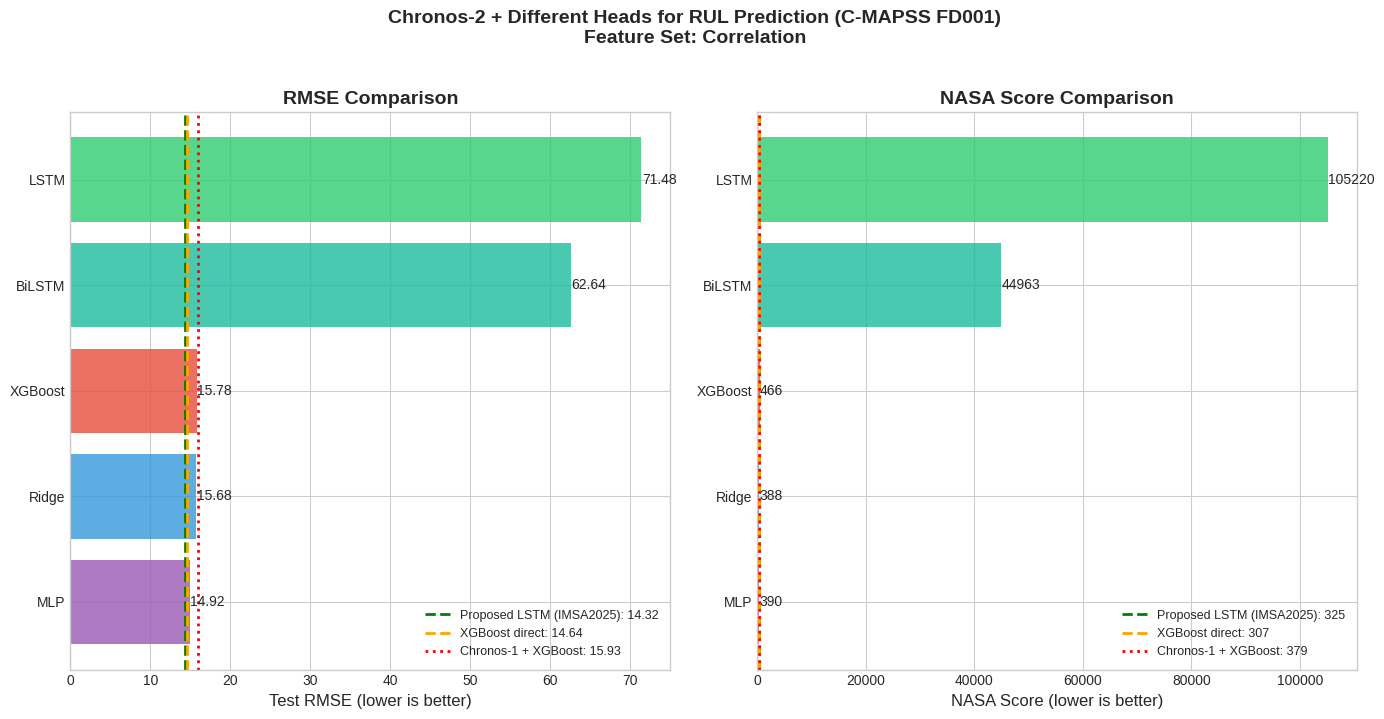

In [14]:
# === D2: Visualization ===
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Filter only correlation features (best performing)
chronos_df = results_df[results_df['Feature_Set'] == 'correlation'].copy()
chronos_df['Label'] = chronos_df['Head']
chronos_df = chronos_df.sort_values('Test_RMSE')

# Color by head type
head_colors = {
    'Ridge': '#3498db',
    'MLP': '#9b59b6',
    'XGBoost': '#e74c3c',
    'LSTM': '#2ecc71',
    'BiLSTM': '#1abc9c'
}
colors = [head_colors.get(h, '#95a5a6') for h in chronos_df['Head']]

# RMSE
ax1 = axes[0]
bars1 = ax1.barh(chronos_df['Label'], chronos_df['Test_RMSE'], color=colors, alpha=0.8)
ax1.axvline(x=14.32, color='green', linestyle='--', linewidth=2, label='Proposed LSTM (IMSA2025): 14.32')
ax1.axvline(x=14.64, color='orange', linestyle='--', linewidth=2, label='XGBoost direct: 14.64')
ax1.axvline(x=15.93, color='red', linestyle=':', linewidth=2, label='Chronos-1 + XGBoost: 15.93')
ax1.set_xlabel('Test RMSE (lower is better)', fontsize=12)
ax1.set_title('RMSE Comparison', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right', fontsize=9)

for bar, val in zip(bars1, chronos_df['Test_RMSE']):
    ax1.text(val + 0.1, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center')

# NASA Score
ax2 = axes[1]
bars2 = ax2.barh(chronos_df['Label'], chronos_df['Test_Score'], color=colors, alpha=0.8)
ax2.axvline(x=325.05, color='green', linestyle='--', linewidth=2, label='Proposed LSTM (IMSA2025): 325')
ax2.axvline(x=307.13, color='orange', linestyle='--', linewidth=2, label='XGBoost direct: 307')
ax2.axvline(x=379.02, color='red', linestyle=':', linewidth=2, label='Chronos-1 + XGBoost: 379')
ax2.set_xlabel('NASA Score (lower is better)', fontsize=12)
ax2.set_title('NASA Score Comparison', fontsize=14, fontweight='bold')
ax2.legend(loc='lower right', fontsize=9)

for bar, val in zip(bars2, chronos_df['Test_Score']):
    ax2.text(val + 5, bar.get_y() + bar.get_height()/2, f'{val:.0f}', va='center')

plt.suptitle('Chronos-2 + Different Heads for RUL Prediction (C-MAPSS FD001)\nFeature Set: Correlation',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/chronos2_heads_comparison_{TIMESTAMP}.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# === D3: Save Results ===
results_df.to_csv(f'{SAVE_DIR}/chronos2_results_{TIMESTAMP}.csv', index=False)

best = results_df.iloc[0].to_dict()
with open(f'{SAVE_DIR}/best_result_{TIMESTAMP}.json', 'w') as f:
    json.dump(best, f, indent=2, default=str)

# Save full comparison with baselines
full_comparison.to_csv(f'{SAVE_DIR}/full_comparison_{TIMESTAMP}.csv', index=False)

summary = {
    'dataset': 'C-MAPSS FD001',
    'window_size': W,
    'rul_cap': RUL_CAP,
    'chronos2_model': CHRONOS2_MODEL,
    'best_model': best['Model'],
    'best_features': best['Feature_Set'],
    'best_head': best['Head'],
    'best_rmse': best['Test_RMSE'],
    'best_score': best['Test_Score'],
    'heads_tested': ['Ridge', 'MLP', 'XGBoost', 'LSTM', 'BiLSTM'],
    'feature_sets_tested': ['correlation', 'aficv'],
    'baselines': {
        'proposed_lstm_imsa2025': {'rmse': 14.32, 'score': 325.05},
        'xgboost_direct': {'rmse': 14.64, 'score': 307.13},
        'chronos1_xgboost': {'rmse': 15.93, 'score': 379.02}
    }
}
with open(f'{SAVE_DIR}/summary_{TIMESTAMP}.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(f"\n✓ Results saved to {SAVE_DIR}")
print(f"\n{'='*60}")
print("BEST CHRONOS-2 RESULT:")
print(f"  Features: {best['Feature_Set']}")
print(f"  Head: {best['Head']}")
print(f"  RMSE: {best['Test_RMSE']}")
print(f"  Score: {best['Test_Score']}")
print('='*60)

print(f"\n{'='*60}")
print("COMPARISON WITH BASELINES:")
print(f"  vs Proposed LSTM (14.32):    {'+' if best['Test_RMSE'] > 14.32 else '-'}{abs(best['Test_RMSE'] - 14.32):.2f} RMSE")
print(f"  vs XGBoost direct (14.64):   {'+' if best['Test_RMSE'] > 14.64 else '-'}{abs(best['Test_RMSE'] - 14.64):.2f} RMSE")
print(f"  vs Chronos-1 + XGB (15.93):  {'+' if best['Test_RMSE'] > 15.93 else '-'}{abs(best['Test_RMSE'] - 15.93):.2f} RMSE")
print('='*60)

NameError: name 'CHRONOS1_MODEL' is not defined

In [14]:
# === D4: Setup for Visualization ===

def get_last_per_unit(y_true, y_pred, units):
    df = pd.DataFrame({'unit': units, 'true': y_true, 'pred': y_pred})
    last_idx = df.groupby('unit').tail(1).index
    return df.loc[last_idx]

fs_name = 'correlation'
predictions = {head: d['y_pred'] for head, d in all_predictions[fs_name].items()}
y_test = all_predictions[fs_name]['Ridge']['y_test']
units_test = all_predictions[fs_name]['Ridge']['units_test']

results_per_unit = {}
for method, y_pred in predictions.items():
    df = get_last_per_unit(y_test, y_pred, units_test)
    results_per_unit[method] = df.sort_values('unit')

colors = {'Ridge': '#3498db', 'MLP': '#2ecc71', 'XGBoost': '#e74c3c'}
markers = {'Ridge': 's', 'MLP': '^', 'XGBoost': 'D'}

print(f"✓ Ready to plot: {list(predictions.keys())}")

Using existing embeddings: train=(17731, 768), test=(10196, 768)
Training Ridge...
Training MLP...
Training XGBoost...


KeyboardInterrupt: 

In [ ]:
# === D5: Combined Plot (All Methods) ===

fig, ax = plt.subplots(figsize=(14, 6))

# Get last predictions per unit
results_per_unit = {}
for method, y_pred in predictions.items():
    df = get_last_per_unit(y_test, y_pred, units_test)
    results_per_unit[method] = df.sort_values('unit')

# X-axis: unit IDs
units = results_per_unit['Ridge']['unit'].values
true_rul = results_per_unit['Ridge']['true'].values

# Plot true RUL
ax.plot(units, true_rul, 'ko-', label='True RUL', linewidth=2, markersize=4)

# Plot predictions
colors = {'Ridge': '#3498db', 'MLP': '#2ecc71', 'XGBoost': '#e74c3c'}
markers = {'Ridge': 's', 'MLP': '^', 'XGBoost': 'D'}

for method, df in results_per_unit.items():
    ax.plot(units, df['pred'].values,
            color=colors[method], marker=markers[method],
            linestyle='--', label=f'{method}', linewidth=1.5, markersize=4, alpha=0.8)

ax.set_xlabel('Test Unit ID', fontsize=12)
ax.set_ylabel('RUL (cycles)', fontsize=12)
ax.set_title('Chronos-2 + Different Heads: True vs Predicted RUL (C-MAPSS FD001)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([units.min()-1, units.max()+1])

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/rul_comparison_all_methods_{TIMESTAMP}.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Combined plot saved")

In [ ]:
# === D6: Separate Plots (One per Method) ===

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (method, df) in enumerate(results_per_unit.items()):
    ax = axes[idx]
    units = df['unit'].values
    true_rul = df['true'].values
    pred_rul = df['pred'].values

    # Calculate metrics
    rmse = np.sqrt(np.mean((true_rul - pred_rul)**2))

    # Plot
    ax.plot(units, true_rul, 'ko-', label='True RUL', linewidth=2, markersize=4)
    ax.plot(units, pred_rul, color=colors[method], marker=markers[method],
            linestyle='--', label=f'Predicted', linewidth=1.5, markersize=4)

    # Fill error region
    ax.fill_between(units, true_rul, pred_rul, alpha=0.2, color=colors[method])

    ax.set_xlabel('Test Unit ID', fontsize=11)
    ax.set_ylabel('RUL (cycles)', fontsize=11)
    ax.set_title(f'Chronos-2 + {method}\nRMSE = {rmse:.2f}', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Per-Unit RUL Predictions (C-MAPSS FD001 - Last Window)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/rul_comparison_separate_{TIMESTAMP}.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Separate plots saved")

In [ ]:
# === D7: Scatter Plot (True vs Predicted) ===

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (method, df) in enumerate(results_per_unit.items()):
    ax = axes[idx]
    true_rul = df['true'].values
    pred_rul = df['pred'].values

    # Scatter plot
    ax.scatter(true_rul, pred_rul, c=colors[method], alpha=0.6, s=50, edgecolors='white')

    # Perfect prediction line
    max_val = max(true_rul.max(), pred_rul.max()) + 10
    ax.plot([0, max_val], [0, max_val], 'k--', linewidth=2, label='Perfect prediction')

    # ±10 tolerance band
    ax.fill_between([0, max_val], [0-10, max_val-10], [0+10, max_val+10],
                    alpha=0.1, color='green', label='±10 cycles')

    # Metrics
    rmse = np.sqrt(np.mean((true_rul - pred_rul)**2))
    mae = np.mean(np.abs(true_rul - pred_rul))

    ax.set_xlabel('True RUL (cycles)', fontsize=11)
    ax.set_ylabel('Predicted RUL (cycles)', fontsize=11)
    ax.set_title(f'Chronos-2 + {method}\nRMSE={rmse:.2f}, MAE={mae:.2f}', fontsize=12, fontweight='bold')
    ax.legend(loc='upper left', fontsize=9)
    ax.set_xlim([0, max_val])
    ax.set_ylim([0, max_val])
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

plt.suptitle('True vs Predicted RUL (C-MAPSS FD001)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/rul_scatter_{TIMESTAMP}.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Scatter plots saved")

In [15]:
# === D5: Best Model (Mean Pooling + MLP) - Prediction vs Reality ===

# Re-extract embeddings with mean pooling for the best combination
fs_name = 'correlation'
data = data_dict[fs_name]

print("Extracting embeddings with MEAN pooling...")
X_train_emb = extract_chronos2_embeddings_v2(chronos2_pipeline, data['X_train'], pooling='mean')
X_test_emb = extract_chronos2_embeddings_v2(chronos2_pipeline, data['X_test'], pooling='mean')
print(f"  Train: {X_train_emb.shape}, Test: {X_test_emb.shape}")

# Train MLP (best head for mean pooling)
print("\nTraining MLP...")
mlp = MLPRegressor(hidden_layer_sizes=(256, 128), max_iter=500,
                   early_stopping=True, random_state=42)
mlp.fit(X_train_emb, data['y_train'])
y_pred = mlp.predict(X_test_emb)

y_test = data['y_test']
units_test = data['units_test']

# Evaluate
rmse, score = evaluate_per_unit(y_test, y_pred, units_test)
print(f"✓ RMSE: {rmse:.2f}, Score: {score:.1f}")

# Get last prediction per unit
def get_last_per_unit(y_true, y_pred, units):
    df = pd.DataFrame({'unit': units, 'true': y_true, 'pred': y_pred})
    last_idx = df.groupby('unit').tail(1).index
    return df.loc[last_idx].sort_values('unit')

results = get_last_per_unit(y_test, y_pred, units_test)
units = results['unit'].values
true_rul = results['true'].values
pred_rul = results['pred'].values

print(f"\nReady to plot: {len(units)} test units")

Extracting embeddings with MEAN pooling...
  Train: (17731, 768), Test: (10196, 768)

Training MLP...
✓ RMSE: 14.43, Score: 336.5

Ready to plot: 100 test units


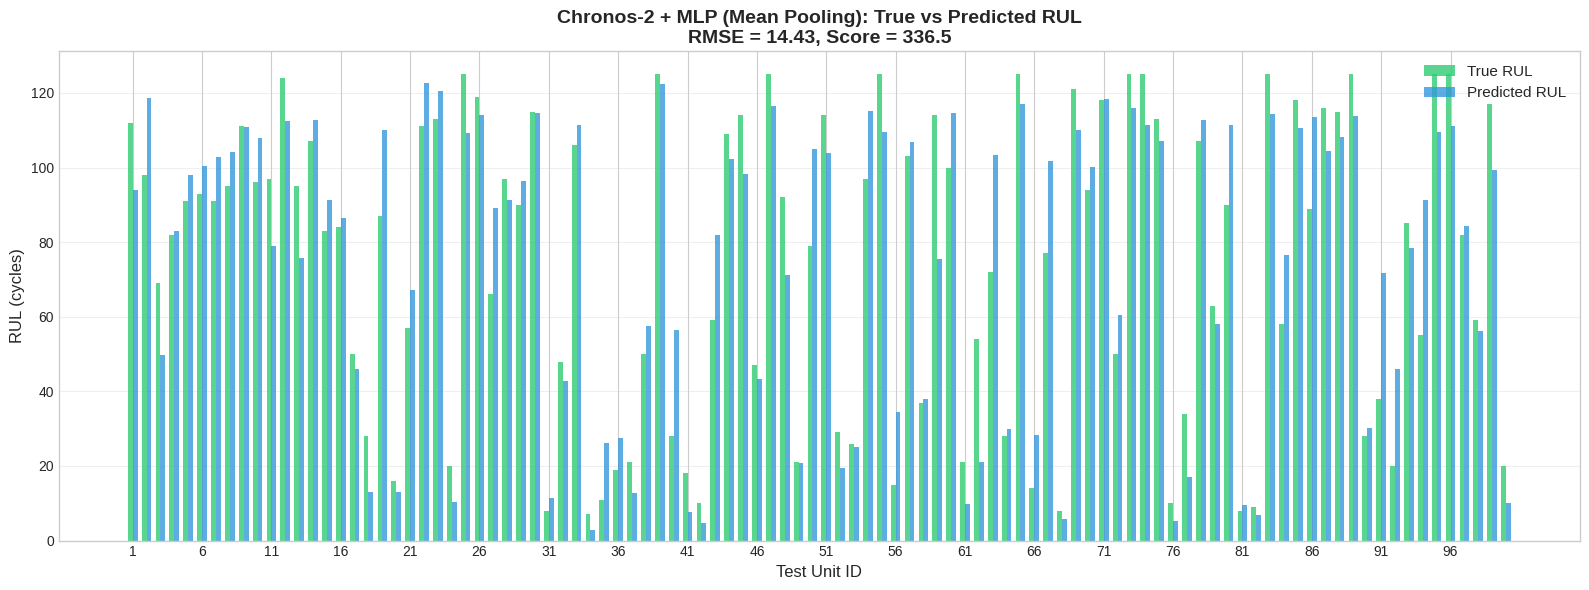

In [16]:
# === D6: Plot 1 - Bar Chart ===

fig, ax = plt.subplots(figsize=(16, 6))

x = np.arange(len(units))
width = 0.35

bars1 = ax.bar(x - width/2, true_rul, width, label='True RUL', color='#2ecc71', alpha=0.8)
bars2 = ax.bar(x + width/2, pred_rul, width, label='Predicted RUL', color='#3498db', alpha=0.8)

ax.set_xlabel('Test Unit ID', fontsize=12)
ax.set_ylabel('RUL (cycles)', fontsize=12)
ax.set_title(f'Chronos-2 + MLP (Mean Pooling): True vs Predicted RUL\nRMSE = {rmse:.2f}, Score = {score:.1f}',
             fontsize=14, fontweight='bold')
ax.set_xticks(x[::5])
ax.set_xticklabels(units[::5])
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/best_model_bar_{TIMESTAMP}.png', dpi=150, bbox_inches='tight')
plt.show()

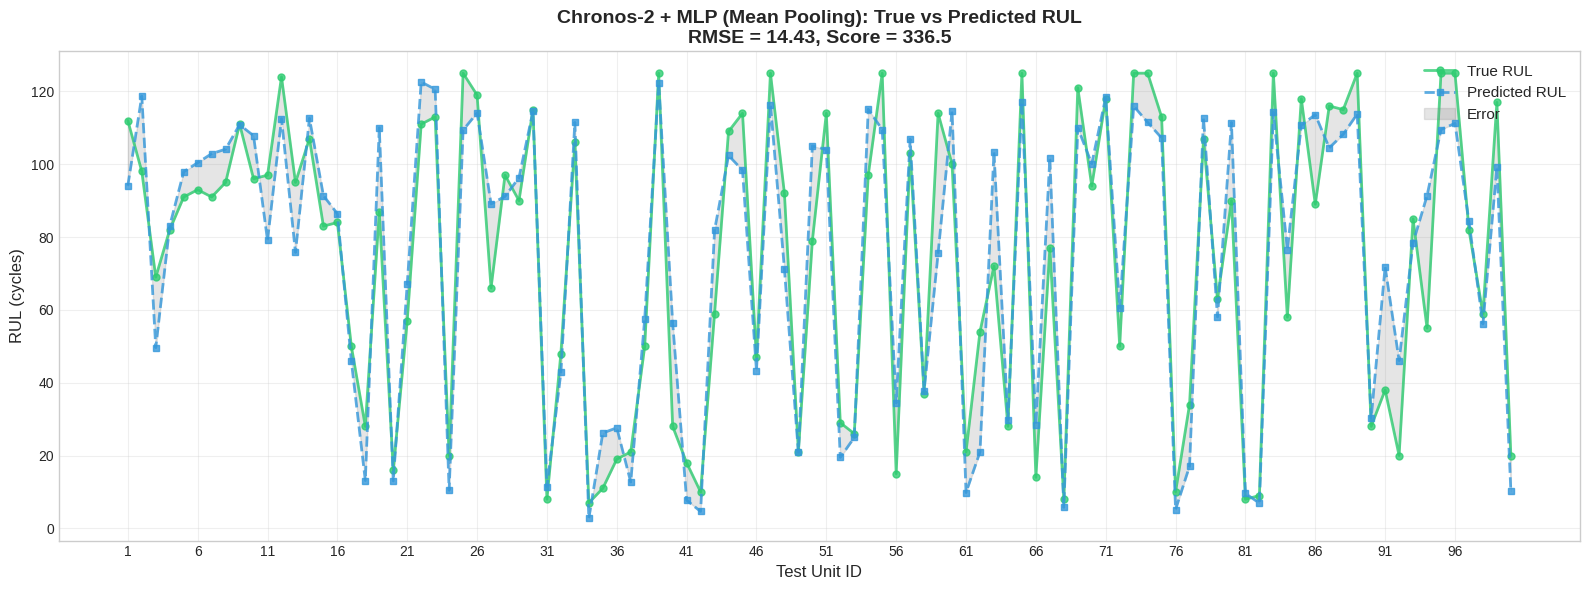

In [18]:
# === D6: Plot 1 - Line Graph ===

fig, ax = plt.subplots(figsize=(16, 6))

x = np.arange(len(units))

# Line plots
ax.plot(x, true_rul, 'o-', label='True RUL', color='#2ecc71', linewidth=2, markersize=5, alpha=0.8)
ax.plot(x, pred_rul, 's--', label='Predicted RUL', color='#3498db', linewidth=2, markersize=5, alpha=0.8)

# Fill between to show error
ax.fill_between(x, true_rul, pred_rul, alpha=0.2, color='gray', label='Error')

ax.set_xlabel('Test Unit ID', fontsize=12)
ax.set_ylabel('RUL (cycles)', fontsize=12)
ax.set_title(f'Chronos-2 + MLP (Mean Pooling): True vs Predicted RUL\nRMSE = {rmse:.2f}, Score = {score:.1f}',
             fontsize=14, fontweight='bold')
ax.set_xticks(x[::5])
ax.set_xticklabels(units[::5])
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/best_model_line_{TIMESTAMP}.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Summary

### Experimental Setup
- **Dataset**: C-MAPSS FD001 (100 train units, 100 test units)
- **Window size**: 30 cycles
- **Feature selection**: Variance+Correlation, AFICv (90% importance)
- **Metrics**: RMSE and NASA Score (per-unit last prediction)

### Model Comparison

| Aspect | Chronos-1 | Chronos-2 |
|--------|-----------|----------|
| Architecture | T5 Encoder-Decoder | Encoder + Group Attention |
| Multivariate | ❌ (process separately) | ✅ Native |
| Parameters | 8M-710M (configurable) | 120M |
| Context Length | 512 | 8192 |

### Files Saved
```
PhD_results/Chronos_Eval_YYYYMMDD_HHMM/
    chronos_results_*.csv
    chronos_comparison_*.png
    best_result_*.json
    summary_*.json
```